<a href="https://colab.research.google.com/github/sowmya-prabha/Weight_compression_Algorithms/blob/main/DNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip install opendatasets --quiet


In [32]:
import opendatasets as od

In [33]:
dataset_url = "https://www.kaggle.com/datasets/hojjatk/mnist-dataset/data"
od.download(dataset_url)

Skipping, found downloaded files in "./mnist-dataset" (use force=True to force download)


In [34]:
!pip install tensorflow

In [35]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_model_optimization as tfmot

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [36]:
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [37]:
print(type(X_train))
print(type(y_train))
print(type(X_test))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [38]:
print(X_test.shape)
print(y_test.shape)
print(X_train.shape)
print(y_train.shape)
print(f"First 10 labels {y_train[:10]}")

(10000, 28, 28)
(10000,)
(60000, 28, 28)
(60000,)
First 10 labels [5 0 4 1 9 2 1 3 1 4]


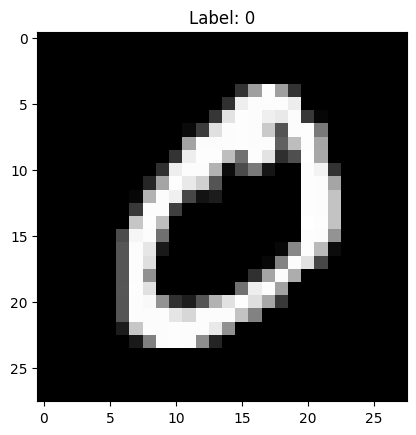

In [39]:
plt.imshow(X_train[1],cmap='gray')
plt.title(f"Label: {y_train[1]}")
plt.show()

In [40]:
X_train = X_train.reshape(60000, 784) #Flatten
X_test = X_test.reshape(10000, 784)

X_train = X_train.astype("float32") / 255.0  #Normalize
X_test = X_test.astype("float32") / 255.0


In [41]:
print("After Flattening:")
print(X_train.shape)
print(X_test.shape)

After Flattening:
(60000, 784)
(10000, 784)


In [42]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(784,)), # Explicit Input layer
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [43]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9082 - loss: 0.3131 - val_accuracy: 0.9607 - val_loss: 0.1366
Epoch 2/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9654 - loss: 0.1150 - val_accuracy: 0.9643 - val_loss: 0.1096
Epoch 3/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9768 - loss: 0.0747 - val_accuracy: 0.9719 - val_loss: 0.0986


In [46]:
loss_before, acc_before = model.evaluate(X_test, y_test)

print("Accuracy Before Compression:", acc_before)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9718 - loss: 0.0885
Accuracy Before Compression: 0.9718000292778015


In [47]:
import numpy as np

weights_before = model.layers[0].get_weights()[0].copy()
bias_before = model.layers[0].get_weights()[1].copy()

print("Shape:", weights_before.shape)

print("Zero Weights Before:", np.sum(weights_before == 0))

Shape: (784, 256)
Zero Weights Before: 0


In [48]:
weights = weights_before.copy()

threshold = np.percentile(np.abs(weights), 50)

weights[np.abs(weights) < threshold] = 0

model.layers[0].set_weights([weights, bias_before])

In [49]:
weights_after = model.layers[0].get_weights()[0]

print("Shape:", weights_after.shape)

print("Zero Weights After:", np.sum(weights_after == 0))

Shape: (784, 256)
Zero Weights After: 100352


In [50]:
loss_after, acc_after = model.evaluate(X_test, y_test)

print("Accuracy After Compression:", acc_after)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9711 - loss: 0.0923
Accuracy After Compression: 0.9710999727249146


In [51]:
print("========== COMPARISON ==========")

print("Accuracy Before :", acc_before)
print("Accuracy After  :", acc_after)

print()

print("Zero Weights Before :", np.sum(weights_before == 0))
print("Zero Weights After  :", np.sum(weights_after == 0))

========== COMPARISON ==========
Accuracy Before : 0.9718000292778015
Accuracy After  : 0.9710999727249146

Zero Weights Before : 0
Zero Weights After  : 100352


In [52]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

optimizers = ['adam', 'sgd', 'rmsprop', 'adagrad', 'adamax', 'nadam']

for opt in optimizers:

    print("="*60)
    print("Optimizer :", opt)
    print("="*60)

    # -----------------------------
    # Build Model
    # -----------------------------
    model = Sequential([
        Dense(256, activation='relu', input_shape=(784,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    # -----------------------------
    # Compile
    # -----------------------------
    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # -----------------------------
    # Train
    # -----------------------------
    model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=128,
        verbose=0
    )

    # -----------------------------
    # Accuracy Before Pruning
    # -----------------------------
    loss_before, acc_before = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    # -----------------------------
    # Save Original Weights
    # -----------------------------
    weights_before = model.layers[0].get_weights()[0].copy()
    bias = model.layers[0].get_weights()[1].copy()

    zero_before = np.sum(weights_before == 0)

    # -----------------------------
    # Manual Weight Pruning (50%)
    # -----------------------------
    weights_after = weights_before.copy()

    threshold = np.percentile(
        np.abs(weights_after),
        50
    )

    weights_after[np.abs(weights_after) < threshold] = 0

    model.layers[0].set_weights([weights_after, bias])

    # -----------------------------
    # Accuracy After Pruning
    # -----------------------------
    loss_after, acc_after = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    zero_after = np.sum(weights_after == 0)

    # -----------------------------
    # Results
    # -----------------------------
    print("Accuracy Before :", round(acc_before,4))
    print("Accuracy After  :", round(acc_after,4))

    print("Zero Weights Before :", zero_before)
    print("Zero Weights After  :", zero_after)

    print()

Optimizer : adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy Before : 0.9762
Accuracy After  : 0.9753
Zero Weights Before : 0
Zero Weights After  : 100352

Optimizer : sgd
Accuracy Before : 0.9274
Accuracy After  : 0.9227
Zero Weights Before : 0
Zero Weights After  : 100352

Optimizer : rmsprop
Accuracy Before : 0.9751
Accuracy After  : 0.9751
Zero Weights Before : 0
Zero Weights After  : 100352

Optimizer : adagrad
Accuracy Before : 0.8882
Accuracy After  : 0.8758
Zero Weights Before : 0
Zero Weights After  : 100352

Optimizer : adamax
Accuracy Before : 0.973
Accuracy After  : 0.9724
Zero Weights Before : 0
Zero Weights After  : 100352

Optimizer : nadam
Accuracy Before : 0.9743
Accuracy After  : 0.9722
Zero Weights Before : 0
Zero Weights After  : 100352



In [54]:
!apt-get install git -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [55]:
!git --version

git version 2.34.1
